# Between-scanner, within-scanner and between-paradigm variability of FC matrices

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve



### Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on during the generalization sessions is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030). For the investigation of the paradigm influence, we keep only the generalization sessions using the Prisma scanner.

In [5]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths
from confounds import get_confounds

# Define filtering parameters
metric = "correlation"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

# Define entities common to all files
entities_base = {
    "subject": "001",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}

## Load FC matrices for the generalization sessions
entities_base_gen = {
    **entities_base,
    "task": "rest",
}
# Get functional connectivity files
files_gen = layout.get(**entities_base_gen, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_gen) == 36, f"Expected 36 FC matrices, got {len(files_gen)}"
df_fc = pd.DataFrame({"filename": files_gen, "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)

## Load confounds
scans_df = get_confounds("/data/datasets/hcph-dataset")
# Keep only the magnitude part of functional scans and first echo
scans_df = scans_df[scans_df["modality"] == "func"]
# Keep only the resting-state scans
scans_df = scans_df[scans_df["task"].isin(["rest", "rsmovie"])]
# Drop columns that are not needed here
scans_df = scans_df.drop(columns=["filename", "caffeine_intake_2h", "caffeine_intake_24h", "room_temp_before", "modality", "task", "day_of_week", "time_of_day"])

# Merge the confounds in
df_fc = pd.merge(
        df_fc, scans_df, on=["subject", "session"], how="inner"
    )

## Load FC matrices from the reliability sessions
entities_base_rel = {
    **entities_base,
    "task": "rsmovie",
}
files_rel = layout.get(**entities_base_rel, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_rel) == 36, f"Expected 36 FC matrices, got {len(files_rel)}"
df_rsmovie = pd.DataFrame({"filename": files_rel, "task": "rsmovie", "subject": "001"})
df_rsmovie["session"] = df_rsmovie["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
df_rsmovie["repetition"] = df_rsmovie.index + 1
# Merge the confounds in
df_rsmovie = pd.merge(df_rsmovie, scans_df, on=["subject", "session"], how="inner")

# Keep only the session with prisma scanner for investigation of paradigm influence
df_fc_paradigm = df_fc[df_fc["scanner"] == "prisma"]
df_fc_paradigm = df_fc_paradigm.drop(columns=["scanner"])
df_fc_paradigm["task"] = "rest"
assert len(df_fc_paradigm) == 12, f"Expected 12 FC matrices for prisma scanner, got {len(df_fc_paradigm)}"

## Concatenate the two dataframes
df_fc_paradigm = pd.concat([df_fc_paradigm, df_rsmovie], ignore_index=True)
assert len(df_fc_paradigm) == 48, f"Expected 48 FC matrices after concatenation, got {len(df_fc_paradigm)}"
')

In [6]:
## Helper function to load the FC matrices from the file paths
load_fc_matrices <- function(df) {
    # Load all FC matrices and add the upper triangle flattened to the dataframe.
    # Since the FC matrix is symmetric, retaining only the upper triangle is sufficient.
    for (i in seq_len(nrow(df))) {
        tsv_file <- df$filename[i]
        mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
        if (grepl("sparseinversecovariance", tsv_file)) {
            # Negate the precision matrix to get partial correlations
            mat <- -mat
        }
        # Flatten the upper triangle of the matrix (excluding diagonal)
        flat <- mat[upper.tri(mat, diag = FALSE)]
        col_names <- paste0("edge", seq_along(flat))
        # Add values to the dataframe
        for (j in seq_along(flat)) {
            df[i, col_names[j]] <- flat[j]
        }
    }
    # Remove the filename column as it is no longer needed
    df$filename <- NULL
    return(df)
}

In [7]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
df_fc <- load_fc_matrices(df_fc)
stopifnot(nrow(df_fc) == 36) #assert statement

df_rsmovie <- as.data.frame(py$df_rsmovie)
df_rsmovie <- load_fc_matrices(df_rsmovie)
stopifnot(nrow(df_rsmovie) == 36)

df_fc_paradigm <- as.data.frame(py$df_fc_paradigm)
df_fc_paradigm <- load_fc_matrices(df_fc_paradigm)
stopifnot(nrow(df_fc_paradigm) == 48)
head(df_fc)

,subject,session,scanner,repetition,acq_time,pe_dir,edge1,edge2,edge3,edge4,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,001,20101060,prisma,1,2024-08-20T21:19:11.542500,AP,0.2827941,0.3701252,0.5657622,0.7358889,⋯,0.1730595,0.3102559,0.2121344,0.2031167,0.4770941,0.2953542,0.1642162,0.4734638,0.4889089,0.3620068
2,001,20102030,vidafit,1,2024-08-20T22:59:30.355000,RL,0.2989734,0.4257047,0.6455861,0.6894252,⋯,0.5119642,0.4776001,0.4571604,0.4440488,0.6165075,0.3442986,0.4719748,0.3867397,0.4178769,0.5189680
3,001,20103034,vida,1,2024-08-21T00:32:54.322500,PA,0.5496409,0.6378708,0.6992454,0.7256449,⋯,0.6684356,0.4696130,0.5322509,0.4993899,0.7612367,0.5316175,0.5145998,0.5403605,0.6864804,0.5960710
4,001,20201060,prisma,2,2024-08-21T20:51:59.287500,RL,0.2171777,0.5192892,0.4158072,0.7086065,⋯,0.4358424,0.4371684,0.2114518,0.3034416,0.4864878,0.3020995,0.4284669,0.3970554,0.5058466,0.4216522
5,001,20202030,vidafit,2,2024-08-21T22:23:23.142500,AP,0.5146798,0.4826543,0.6256755,0.6719204,⋯,0.6440360,0.5486310,0.5267422,0.4705275,0.6739694,0.5031739,0.4826841,0.5139879,0.5398819,0.5300936
6,001,20203034,vida,2,2024-08-22T00:04:15.010000,RL,0.5096338,0.6318354,0.6954506,0.7096535,⋯,0.6452073,0.5660315,0.5724041,0.4610906,0.6353785,0.5021469,0.5146907,0.4986800,0.5097432,0.6179405


## Intra-class correlation coefficient (ICC) to quantify between-scanner variability

In [10]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Iterate over all edges
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[grepl("^edge", col_names)]
if (any(!grepl("^edge", edge_keys))) {
    stop("All elements in edge_keys must contain 'edge'")
}
for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
head(df_icc)
head(icc_vals)

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(edge)

  # Now:
  data %>% select(all_of(edge))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


prisma,vidafit,vida
<dbl>,<dbl>,<dbl>
0.3620068,0.5189680,0.5960710
0.4216522,0.5300936,0.6179405
0.3304195,0.5457828,0.5529241
0.5405864,0.3387351,0.3527906
0.5553758,0.6012507,0.3855313
0.5059431,0.5073618,0.4913253


,edge,ICC
,<chr>,<dbl>
1,edge1,0.05878540
2,edge2,0.07420592
3,edge3,-0.02879484
4,edge4,-0.34783099
5,edge5,-0.07901565
6,edge6,-0.10314388


Mean ICC across edges: 0.1249396 
Median ICC across edges: 0.1129433 


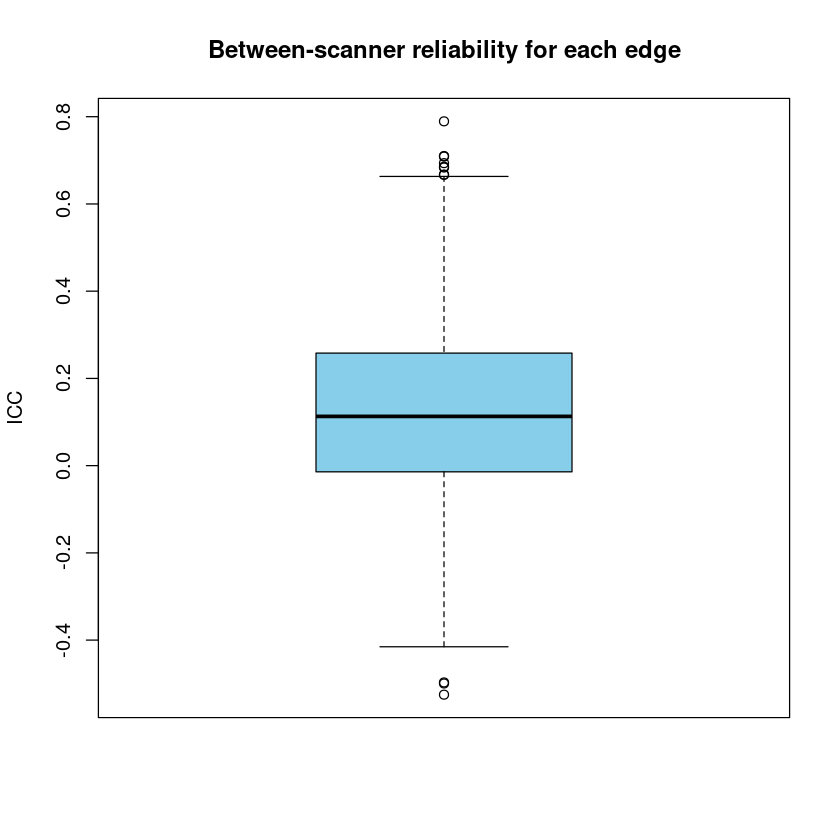

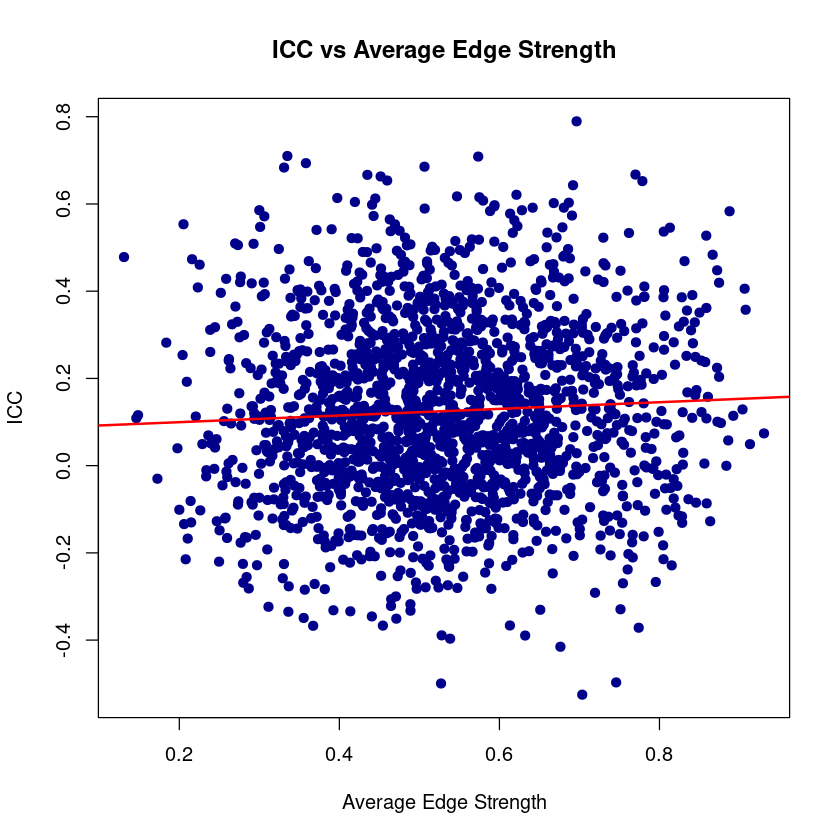

In [ ]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-scanner reliability for each edge", ylab = "ICC", col = "skyblue")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_fc[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    main = "ICC vs Average Edge Strength",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

In [ ]:
icc_between <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), stringsAsFactors = FALSE)

# Iterate over all possible combinations of repetition numbers for the 3 scanners
scanners <- unique(df_fc$scanner)
for (rep1 in unique(df_fc$repetition)) {
  for (rep2 in unique(df_fc$repetition)) {
    for (rep3 in unique(df_fc$repetition)) {

        # Extract that permutation of repetitions
        reps <- c(rep1, rep2, rep3)
        df_rep <- data.frame()
        for (i in 1:3) {
          df_one <- subset(df_fc, scanner == scanners[i] & repetition == reps[i])
          df_rep <- rbind(df_rep, df_one)
        }

        # Keep only the edge column and trasnpose the dataframe
        df_edges <- t(df_rep[, edge_keys])  # rows: edges, cols: scanners
        colnames(df_edges) <- scanners

        # Compute ICC(2,1)
        icc_val <- icc(df_edges, model = "twoway", type = "agreement", unit = "single")$value

        # Store the results
        icc_between <- rbind(
            icc_between,
            data.frame(
            variability_type = "between-scanner",
            task = "rest",
            scanner = NA,
            repetition = paste0(rep1, "-", rep2, "-", rep3),
            ICC = icc_val,
            summary_statistic = NA
            )
        )  
    }
  }
}
head(df_rep)
icc_between

,subject,session,scanner,repetition,edge1,edge2,edge3,edge4,edge5,edge6,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
36,001,21202060,prisma,12,0.3995341,0.4532716,0.7270787,0.7265083,0.3396650,0.3066537,⋯,0.5357756,0.5279141,0.4844928,0.3835809,0.5800909,0.3217235,0.4553063,0.4670414,0.5013658,0.6281675
34,001,21201030,vidafit,12,0.2207215,0.3155374,0.6377107,0.7771281,0.1729692,0.3767742,⋯,0.3697475,0.2581914,0.2360812,0.2896772,0.5450486,0.3004227,0.3408289,0.3524414,0.4587018,0.2901794
35,001,21202034,vida,12,0.3348681,0.3999343,0.6203486,0.6305883,0.1123629,0.1841879,⋯,0.5677531,0.4871123,0.4053256,0.3718582,0.5936710,0.3764830,0.4621020,0.3729554,0.3276582,0.5341707


variability_type,task,scanner,repetition,ICC,summary_statistic
<chr>,<chr>,<lgl>,<chr>,<dbl>,<lgl>
between-scanner,rest,NA,1-1-1,0.4511081,NA
between-scanner,rest,NA,1-1-2,0.5333519,NA
between-scanner,rest,NA,1-1-3,0.5412338,NA
between-scanner,rest,NA,1-1-4,0.6072687,NA
between-scanner,rest,NA,1-1-5,0.5261444,NA
between-scanner,rest,NA,1-1-6,0.5230982,NA
between-scanner,rest,NA,1-1-7,0.5068974,NA
between-scanner,rest,NA,1-1-8,0.5453563,NA
between-scanner,rest,NA,1-1-9,0.3827245,NA


Mean ICC across edges: 0.5817959 
Quantiles (25%, median, 75%): 0.4858799 0.5488128 0.6563669 


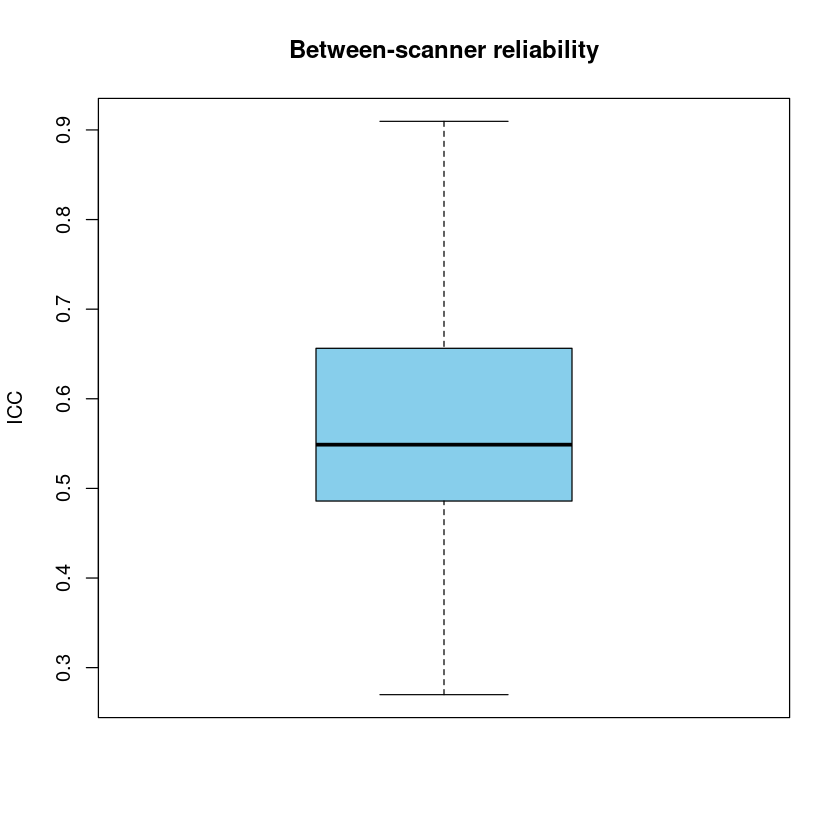

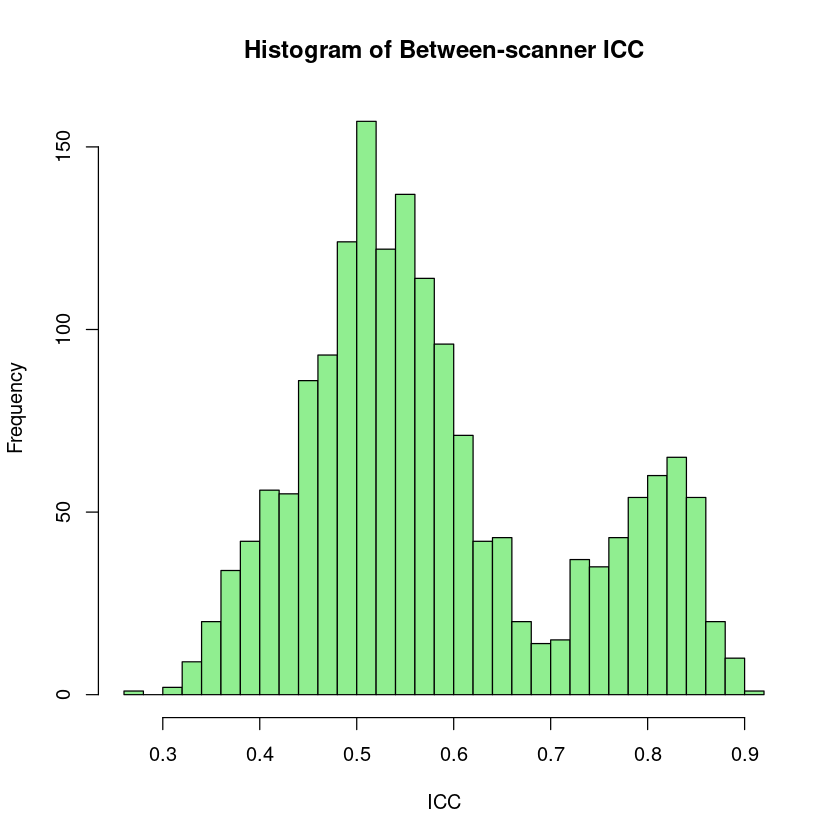

In [ ]:
mean_icc <- mean(icc_between$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_between$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_between <- rbind(
    icc_between,
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA)
)

boxplot(icc_between$ICC, main = "Between-scanner reliability", ylab = "ICC", col = "skyblue")
hist(icc_between$ICC, breaks = 30, main = "Histogram of Between-scanner ICC", xlab = "ICC", col = "skyblue")

In [ ]:
icc_between

,variability_type,task,scanner,repetition,ICC,summary_statistic
,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>
1,between-scanner,rest,NA,1-1-1,0.4511081,NA
2,between-scanner,rest,NA,1-1-2,0.5333519,NA
3,between-scanner,rest,NA,1-1-3,0.5412338,NA
4,between-scanner,rest,NA,1-1-4,0.6072687,NA
5,between-scanner,rest,NA,1-1-5,0.5261444,NA
6,between-scanner,rest,NA,1-1-6,0.5230982,NA
7,between-scanner,rest,NA,1-1-7,0.5068974,NA
8,between-scanner,rest,NA,1-1-8,0.5453563,NA
9,between-scanner,rest,NA,1-1-9,0.3827245,NA


## ICC to quantify intra-scanner variability when using standard resting-state

Let's quantify the intra-scanner reliability of FC estimates when using the standard fixation cross task for resting-state.

### Using all 12 sessions

In [ ]:
icc_within_rest <- list()
for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    df_scanner <- t(df_scanner[, edge_keys])
    icc_within_rest[[scanner]] <- icc(df_scanner, model = "twoway", type = "agreement", unit = "single")$value
    cat(sprintf("ICC of for %s scanner: %.4f\n", scanner, icc_within_rest[[scanner]]))
}
head(df_scanner)

ICC of for prisma scanner: 0.5600
ICC of for vidafit scanner: 0.5330
ICC of for vida scanner: 0.6345


,3,6,8,11,14,16,19,23,27,30,31,35
edge1,0.5496409,0.5096338,0.4131504,0.4449821,0.4811377,0.4517719,0.14202430,0.4132667,0.6015462,0.4562355,0.4532706,0.3348681
edge2,0.6378708,0.6318354,0.3158849,0.5041109,0.5994747,0.5578053,0.58822103,0.5496495,0.6282911,0.4788228,0.5092740,0.3999343
edge3,0.6992454,0.6954506,0.7255366,0.7121464,0.6295779,0.8051219,0.15598399,0.7147821,0.7653149,0.6726379,0.7430331,0.6203486
edge4,0.7256449,0.7096535,0.6781975,0.7078274,0.7546007,0.7273291,0.74348573,0.6888926,0.6716462,0.6576057,0.6938245,0.6305883
edge5,0.4162345,0.3095280,0.3174185,0.3909103,0.3908073,0.4687818,0.08717465,0.4091270,0.4564391,0.3178301,0.2573947,0.1123629
edge6,0.5537715,0.4565463,0.3077499,0.4390451,0.5227392,0.5188716,0.59198707,0.4663180,0.4230545,0.2656652,0.2658177,0.1841879


### Bootstrap all possible pairs of repetitions

In [ ]:
icc_intra_rest <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), stringsAsFactors = FALSE)

for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    # Iterate over all possible pairs of repetition
    for (rep1 in 1:11) {
      # Ensure rep2 is always greater than rep1 to avoid duplicates
      for (rep2 in (rep1+1):12) {

            # Extract that permutation of repetitions
            df_rep <- rbind(subset(df_scanner, repetition == rep1), subset(df_scanner, repetition == rep2))
            # Compute how many days apart the two repetitions are
            days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
            
            #Keep only the edge column and transpose the dataframe
            df_rep <- t(df_rep[, edge_keys])

            # Compute ICC(2,1)
            icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
            icc_intra_rest <- rbind(icc_intra_rest, data.frame(variability_type = "within-scanner", task="rest", scanner=scanner, repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff))
        }
    }
}
head(df_rep)
icc_intra_rest

,31,35
edge1,0.4532706,0.3348681
edge2,0.5092740,0.3999343
edge3,0.7430331,0.6203486
edge4,0.6938245,0.6305883
edge5,0.2573947,0.1123629
edge6,0.2658177,0.1841879


variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff
<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>
within-scanner,rest,prisma,1-2,0.8104636,NA,1
within-scanner,rest,prisma,1-3,0.7115025,NA,2
within-scanner,rest,prisma,1-4,0.4187486,NA,3
within-scanner,rest,prisma,1-5,0.4241301,NA,4
within-scanner,rest,prisma,1-6,0.7735494,NA,5
within-scanner,rest,prisma,1-7,0.5158890,NA,7
within-scanner,rest,prisma,1-8,0.4740944,NA,9
within-scanner,rest,prisma,1-9,0.4213153,NA,9
within-scanner,rest,prisma,1-10,0.7342280,NA,11


Scanner: prisma 
Mean ICC across edges: 0.5645198 
Quantiles (25%, median, 75%): 0.3876615 0.4742587 0.7784872 


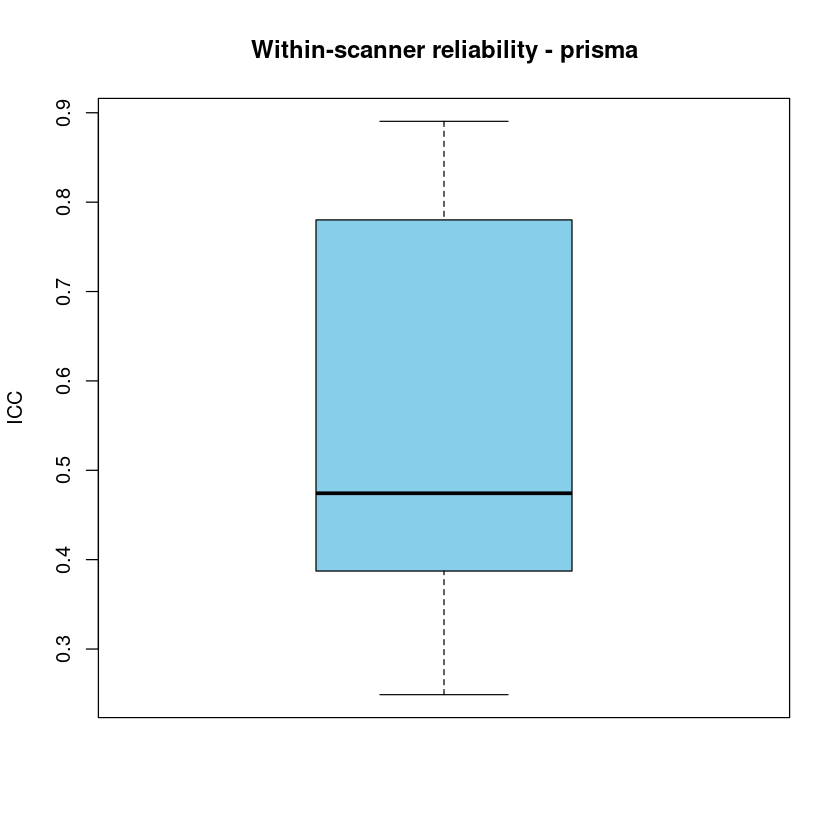

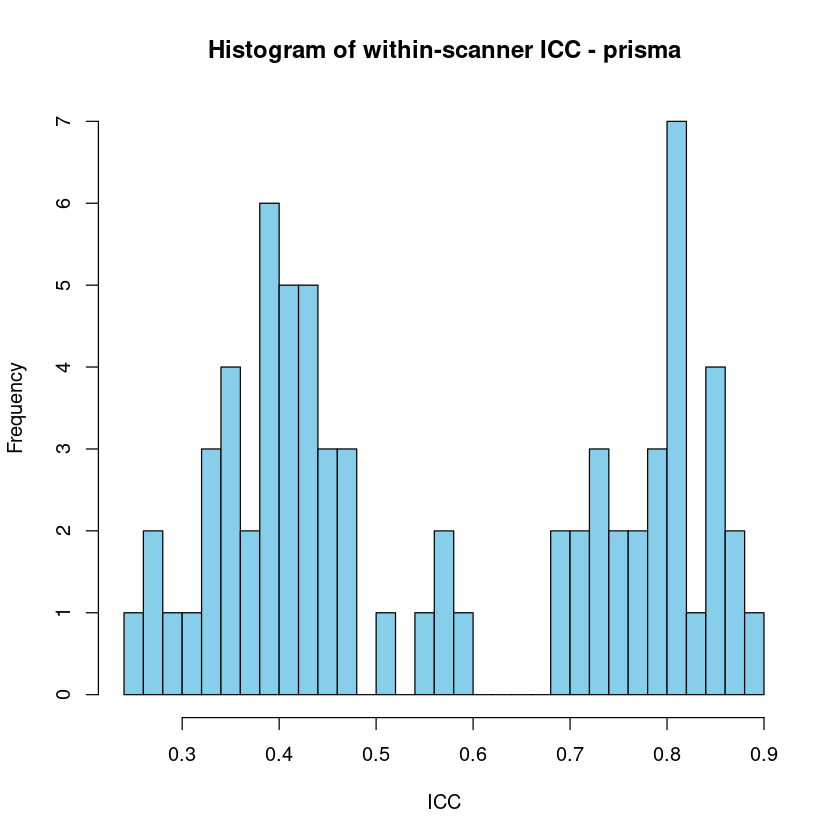

Scanner: vidafit 
Mean ICC across edges: 0.5592567 
Quantiles (25%, median, 75%): 0.3018545 0.5652438 0.8093765 


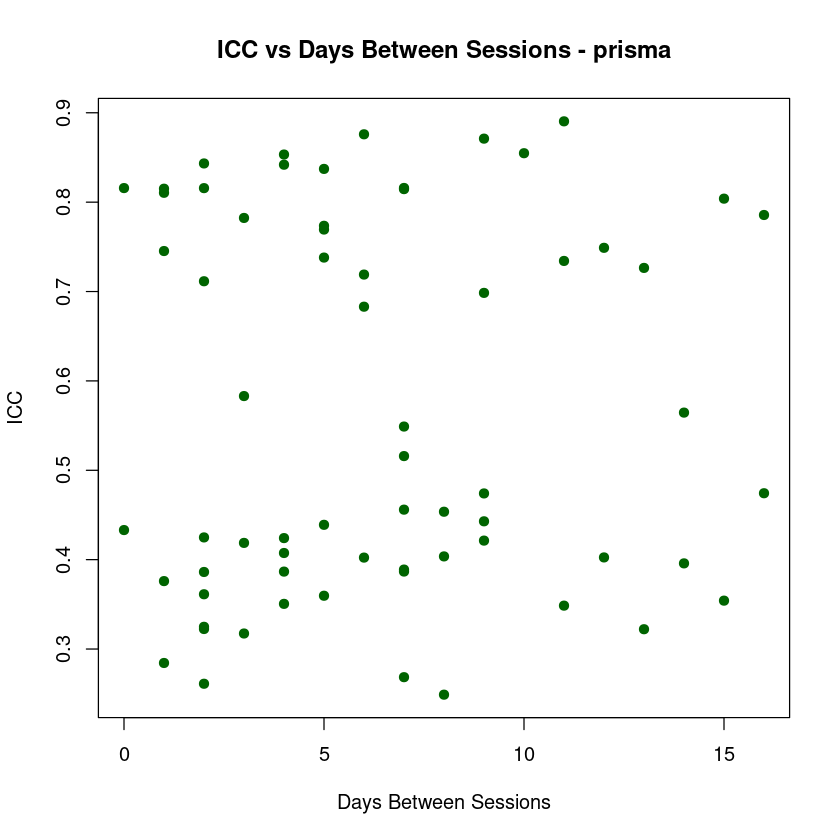

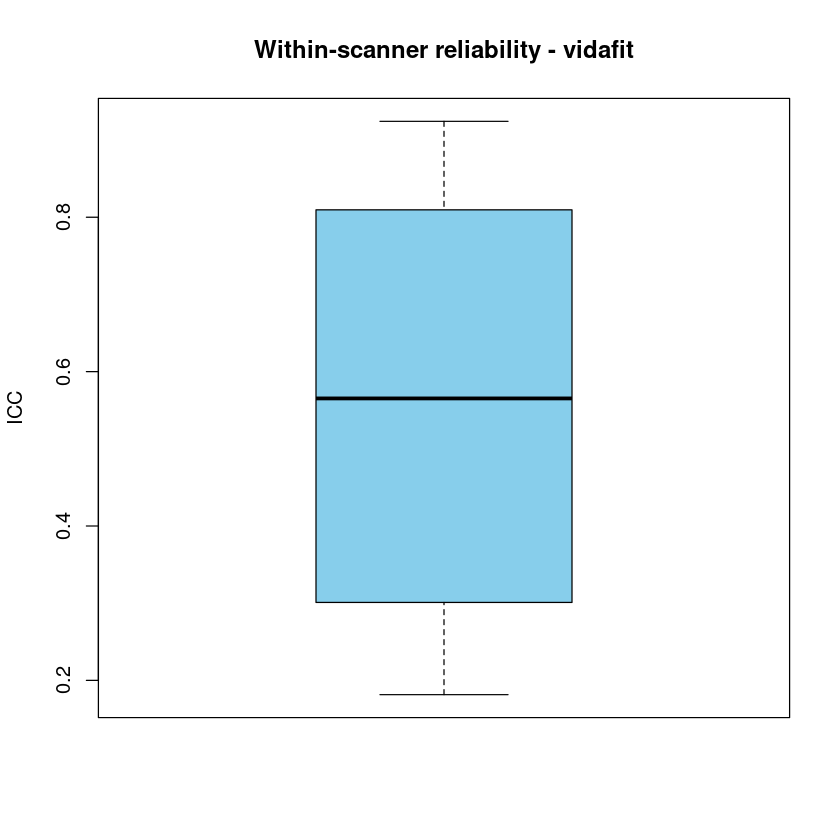

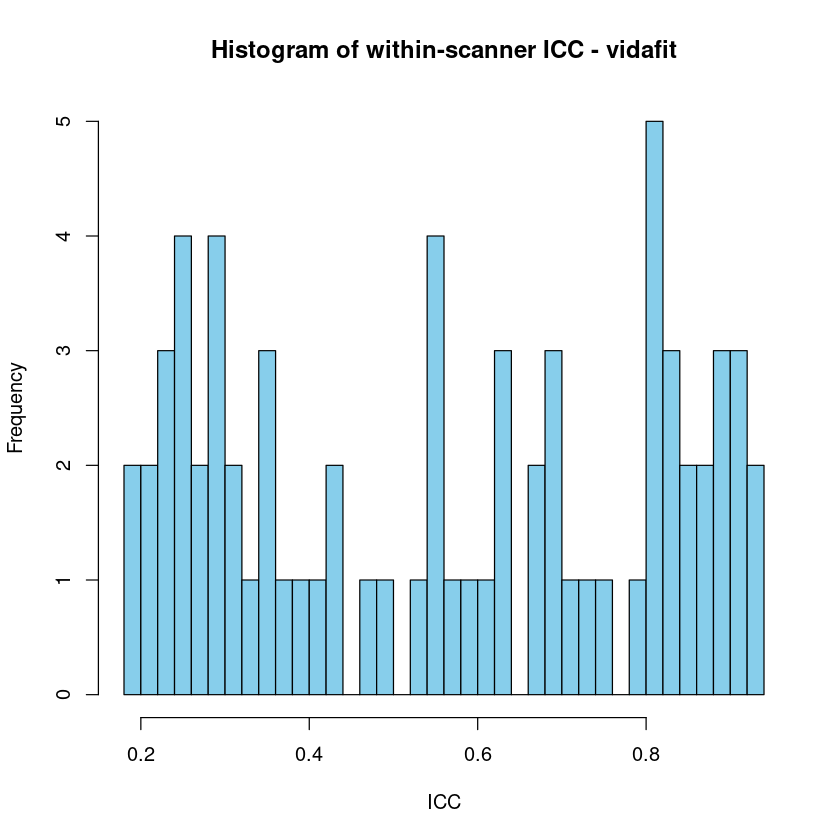

Scanner: vida 
Mean ICC across edges: 0.6457037 
Quantiles (25%, median, 75%): 0.5282213 0.6717594 0.795843 


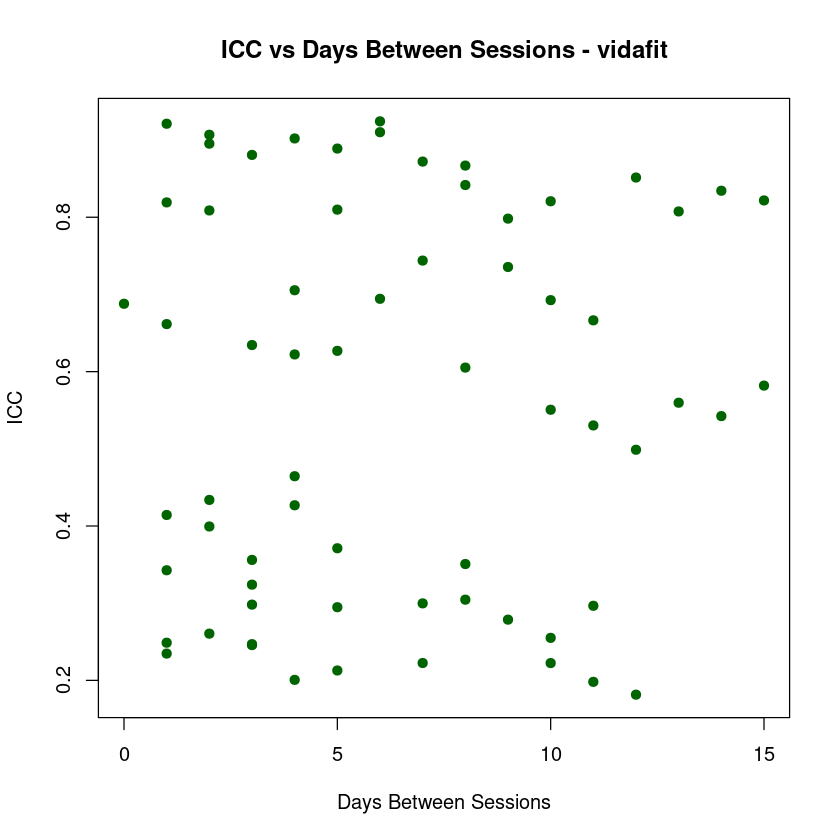

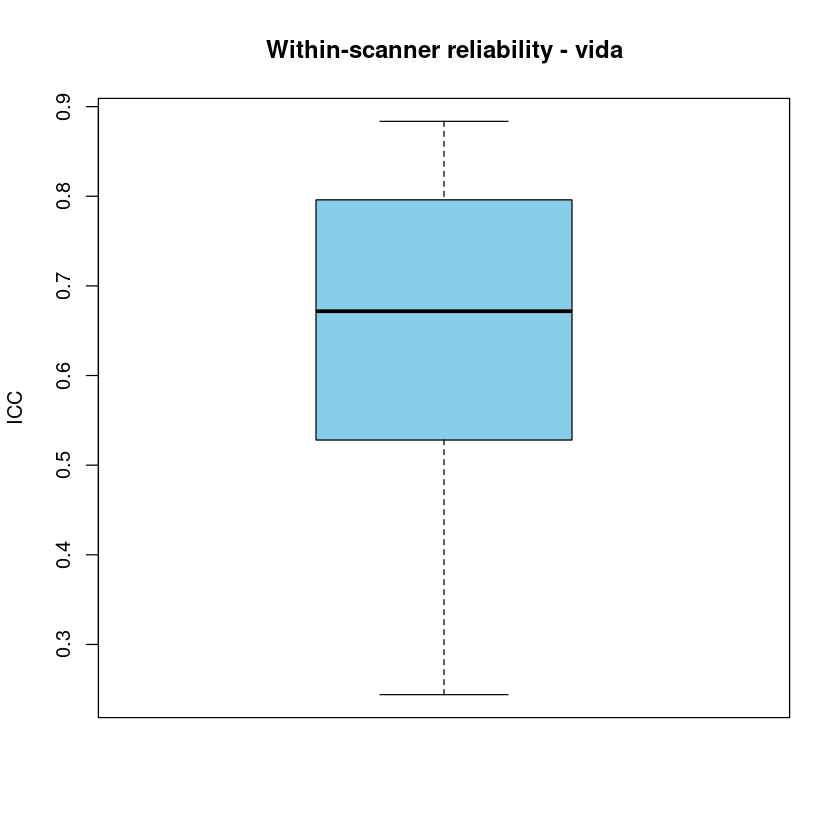

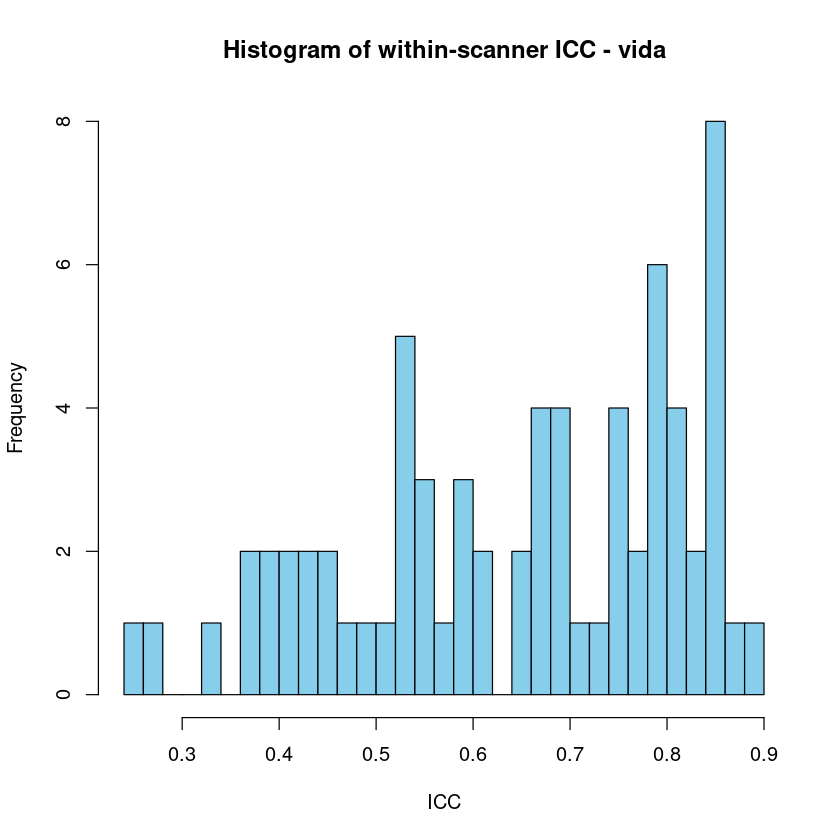

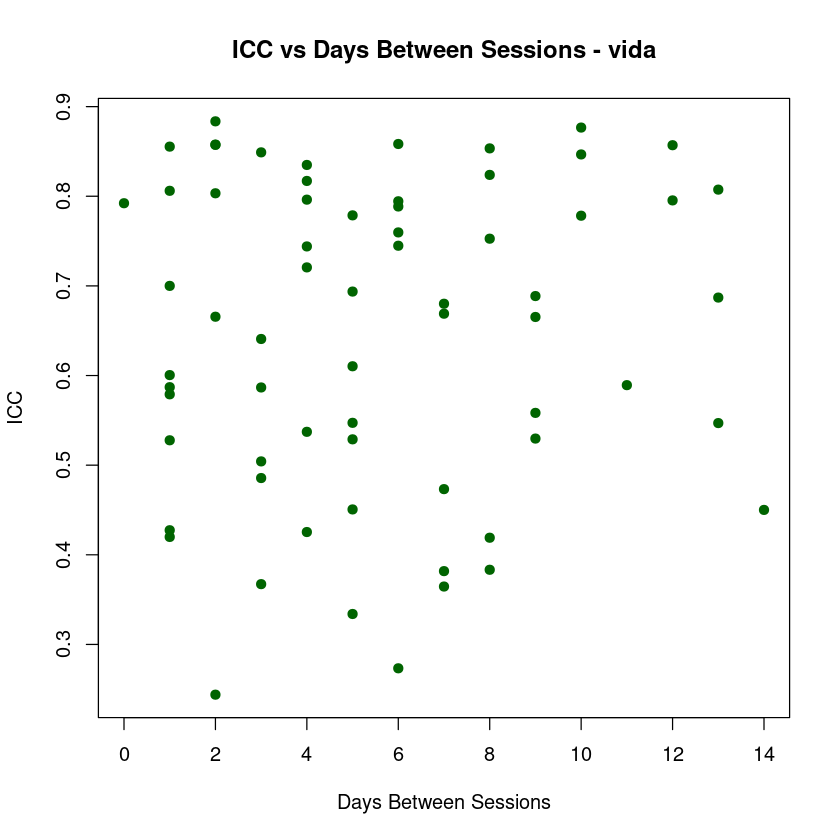

In [20]:
for (scanner in unique(df_fc$scanner)) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    cat("Scanner:", scanner, "\n")
    cat("Mean ICC across edges:", mean_icc, "\n")
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
    cat("Quantiles (25%, median, 75%):", quantiles, "\n")

    icc_intra_rest <- rbind(
        icc_intra_rest,
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA)
    )

    boxplot(icc_intra_rest_scanner$ICC, main = paste("Within-scanner reliability -", scanner), ylab = "ICC", col = "skyblue")
    hist(icc_intra_rest_scanner$ICC, breaks = 30, main = paste("Histogram of within-scanner ICC -", scanner), xlab = "ICC", col = "skyblue")

    plot(
        icc_intra_rest_scanner$days_diff, icc_intra_rest_scanner$ICC,
        xlab = "Days Between Sessions",
        ylab = "ICC",
        main = paste("ICC vs Days Between Sessions -", scanner),
        pch = 19, col = "darkgreen"
    )
}

## ICC to quantify intra-scanner variability when using naturalistic movie

### Using all 36 sessions

In [ ]:
df_intra_rsmovie <- t(df_rsmovie[, edge_keys])
head(df_intra_rsmovie)
icc_val_intra_rsmovie <- icc(df_intra_rsmovie, model = "twoway", type = "agreement", unit = "single")$value
cat(sprintf("ICC for rsmovie: %.4f\n", icc_val_intra_rsmovie))

edge1,0.6216386,0.6403972,0.5412989,0.5346348,0.6104283,0.6035920,0.4466778,0.5050477,0.5457476,0.4679785,⋯,0.4544409,0.5153529,0.5399256,0.5702904,0.5435963,0.4820986,0.3642394,0.4611147,0.5162571,0.3266557
edge2,0.5941284,0.6621736,0.5264868,0.5345418,0.5184101,0.5604684,0.4374828,0.5460433,0.5107944,0.4278021,⋯,0.4923441,0.5952549,0.5841836,0.6445598,0.5662279,0.5802214,0.5269814,0.6362241,0.6555242,0.4594529
edge3,0.7133108,0.6845539,0.5850952,0.7297089,0.6750612,0.7381508,0.5461094,0.6531540,0.6263609,0.5706040,⋯,0.6516860,0.6295478,0.7052182,0.6908451,0.7591276,0.6104920,0.4961447,0.6615232,0.6219265,0.5014879
edge4,0.7408829,0.7714371,0.7457973,0.7591273,0.7632487,0.7389312,0.7470424,0.7875297,0.7609913,0.7715509,⋯,0.7342332,0.7985510,0.6935204,0.6814568,0.7530195,0.6772000,0.6578069,0.6618083,0.6505799,0.6379796
edge5,0.5368403,0.4925515,0.4392278,0.4969488,0.5269248,0.4902849,0.3974737,0.4672775,0.3960080,0.3813823,⋯,0.2556588,0.4521184,0.3283802,0.5248521,0.4698423,0.4506773,0.3867090,0.4423098,0.3995207,0.3442520
edge6,0.5454009,0.5587658,0.4729301,0.4852340,0.5158932,0.5434923,0.3848835,0.4091123,0.2955827,0.2487566,⋯,0.2095474,0.3972067,0.3930193,0.4314876,0.5344769,0.4469067,0.3842306,0.5614531,0.4758118,0.3496748


ICC for rsmovie: 0.7783


### Bootstrap to permute through all possible pairs of repetitions

In [26]:
icc_intra_rsmovie <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), stringsAsFactors = FALSE)

# Iterate over all possible pairs of repetition
for (rep1 in 1:35) {
  # Ensure rep2 is always greater than rep1 to avoid duplicates
  for (rep2 in (rep1+1):36) {

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_rsmovie, repetition == rep1), subset(df_rsmovie, repetition == rep2))
        # Compute how many days apart the two repetitions are
        days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
        
        #Keep only the edge column and transpose the dataframe
        df_rep <- t(df_rep[, edge_keys])

        # Compute ICC(2,1)
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_intra_rsmovie <- rbind(icc_intra_rsmovie, data.frame(variability_type = "within-scanner", task="rsmovie", scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff))
    }
}
head(df_rep)
icc_intra_rsmovie

,35,36
edge1,0.5162571,0.3266557
edge2,0.6555242,0.4594529
edge3,0.6219265,0.5014879
edge4,0.6505799,0.6379796
edge5,0.3995207,0.3442520
edge6,0.4758118,0.3496748


variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff
<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>
within-scanner,rsmovie,prisma,1-2,0.8197148,NA,1
within-scanner,rsmovie,prisma,1-3,0.8884523,NA,1
within-scanner,rsmovie,prisma,1-4,0.9148769,NA,2
within-scanner,rsmovie,prisma,1-5,0.8285133,NA,2
within-scanner,rsmovie,prisma,1-6,0.7563433,NA,3
within-scanner,rsmovie,prisma,1-7,0.7923917,NA,3
within-scanner,rsmovie,prisma,1-8,0.8678229,NA,4
within-scanner,rsmovie,prisma,1-9,0.7944283,NA,4
within-scanner,rsmovie,prisma,1-10,0.8338652,NA,5


Mean ICC across edges: 0.7830889 
Quantiles (25%, median, 75%): 0.7300636 0.8058263 0.8453384 
Quantiles (25%, median, 75%): 0.7300636 0.8058263 0.8453384 


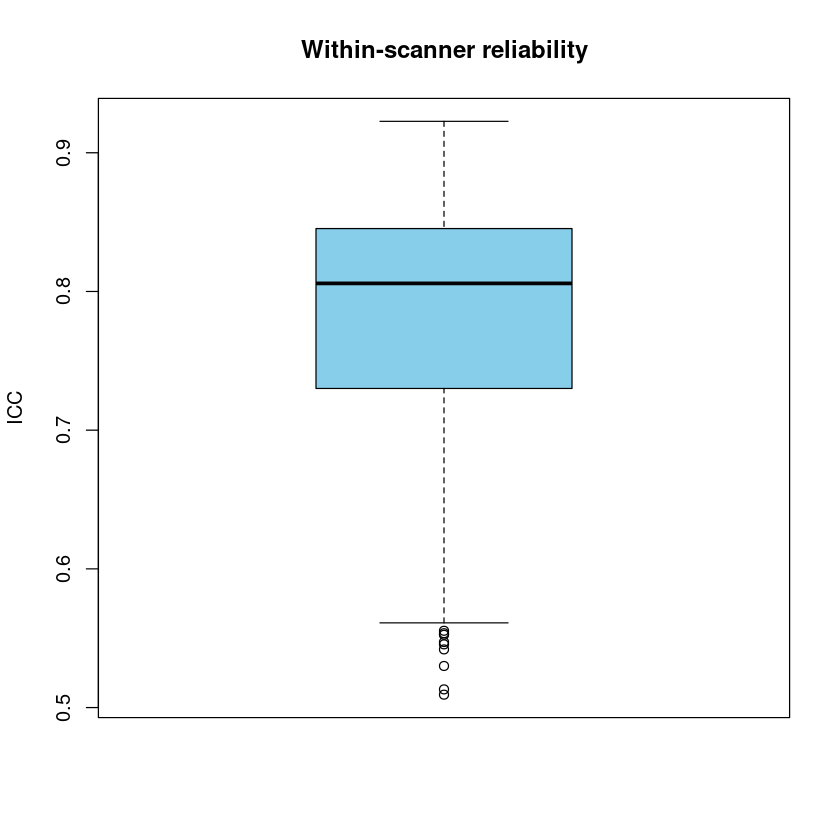

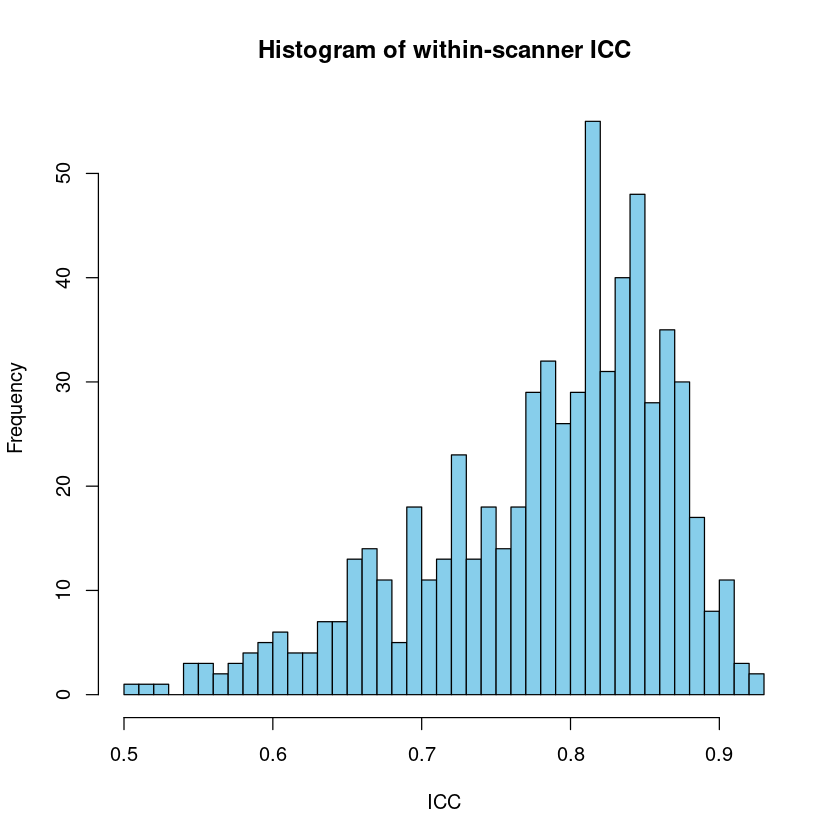

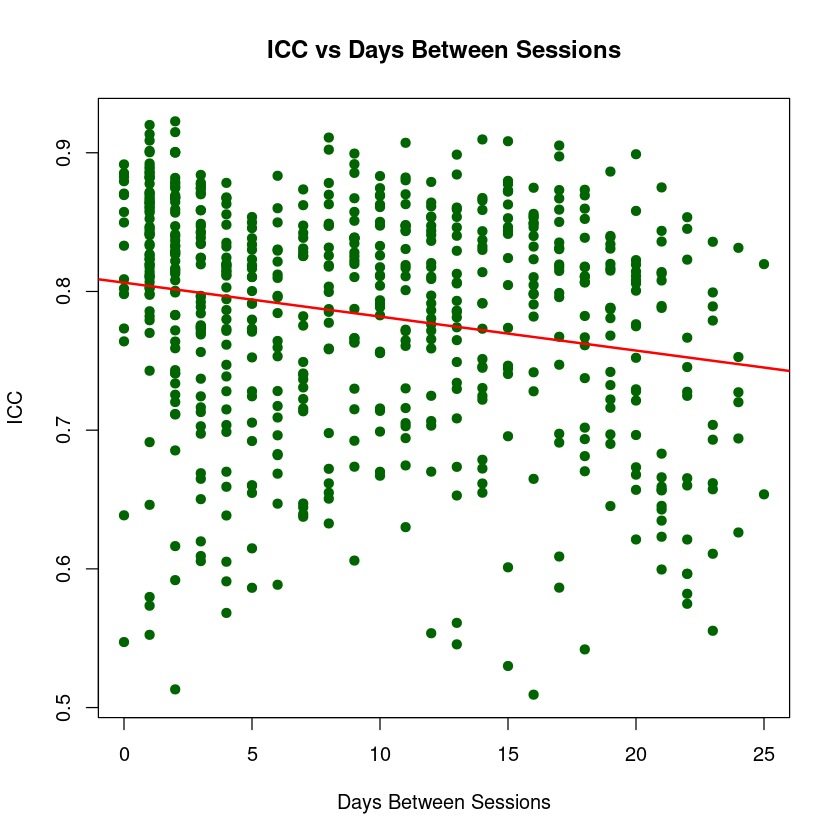

In [30]:
mean_icc <- mean(icc_intra_rsmovie$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_intra_rsmovie$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_intra_rsmovie <- rbind(
    icc_intra_rsmovie,
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA)
)

boxplot(icc_intra_rsmovie$ICC, main = "Within-scanner reliability", ylab = "ICC", col = "skyblue")
hist(icc_intra_rsmovie$ICC, breaks = 30, main = "Histogram of within-scanner ICC", xlab = "ICC", col = "skyblue")

plot(
        icc_intra_rsmovie$days_diff, icc_intra_rsmovie$ICC,
        xlab = "Days Between Sessions",
        ylab = "ICC",
        main = paste("ICC vs Days Between Sessions"),
        pch = 19, col = "darkgreen"
    )
abline(lm(ICC ~ days_diff, data = icc_intra_rsmovie), col = "red", lwd = 2)

## ICC to quantify variability across paradigms

In [ ]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Randomly select 12 sessions from the rsmovie task because we need to have the same number of sessions for each task to be able to compute ICC
selected_sessions <- sample(unique(df_fc_paradigm$repetition[df_fc_paradigm$task == "rsmovie"]), 12)
df_paradigm <- df_fc_paradigm[df_fc_paradigm$repetition %in% selected_sessions | df_fc_paradigm$task == "rest", ]

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_paradigm[, c( "task", edge)]
    df_icc <- pivot_wider(df_icc, names_from = task, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(rest, rsmovie))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_vals)

rest,rsmovie
<dbl>,<dbl>
0.3620068,0.5179920
0.4216522,0.5910796
0.3304195,0.6311306
0.5405864,0.3894608
0.5553758,0.6059001
0.5059431,0.5018360
0.4990836,0.5694896
0.6696954,0.6330315
0.4960707,0.6943303


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.1430949
2,edge2,-0.2792443
3,edge3,-0.1973707
4,edge4,-0.1577221
5,edge5,-0.1977967
6,edge6,-0.4220921


Mean ICC across edges: -0.0112824 
Median ICC across edges: -0.007466763 


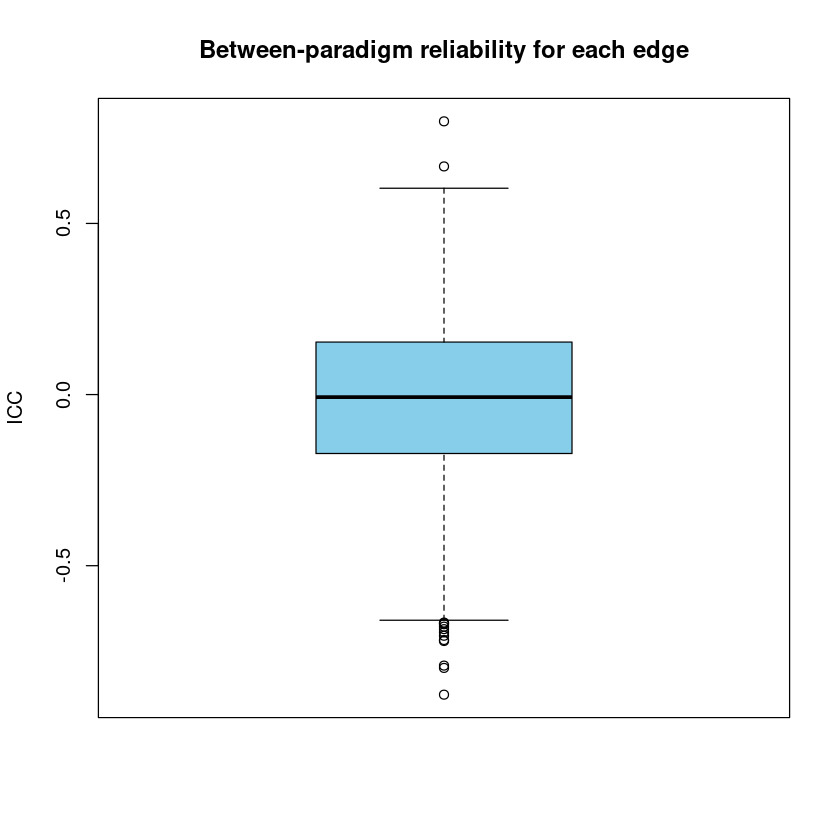

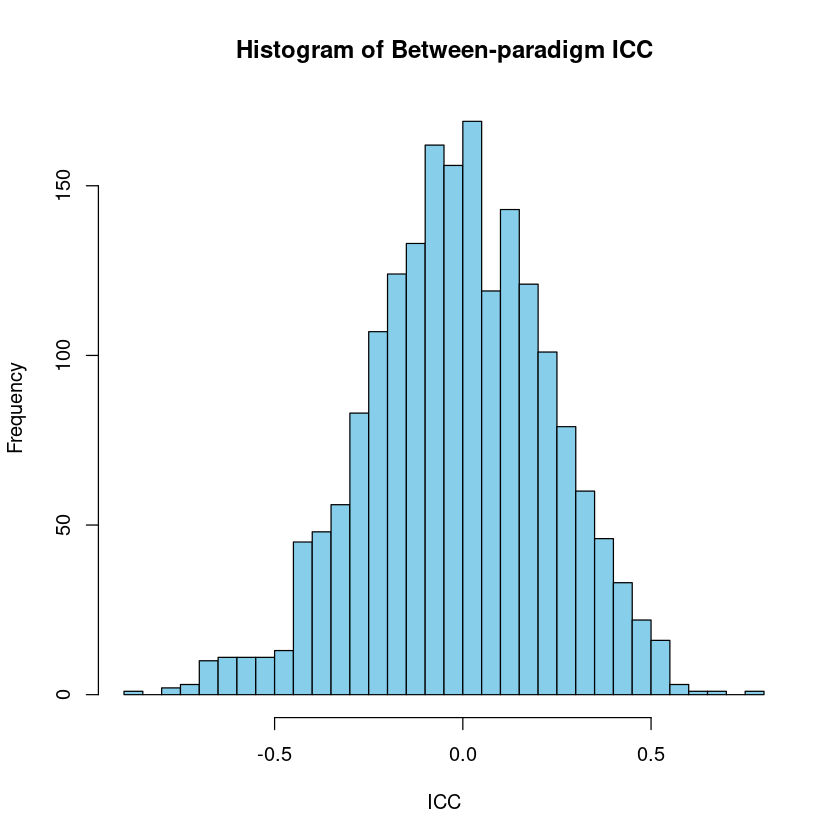

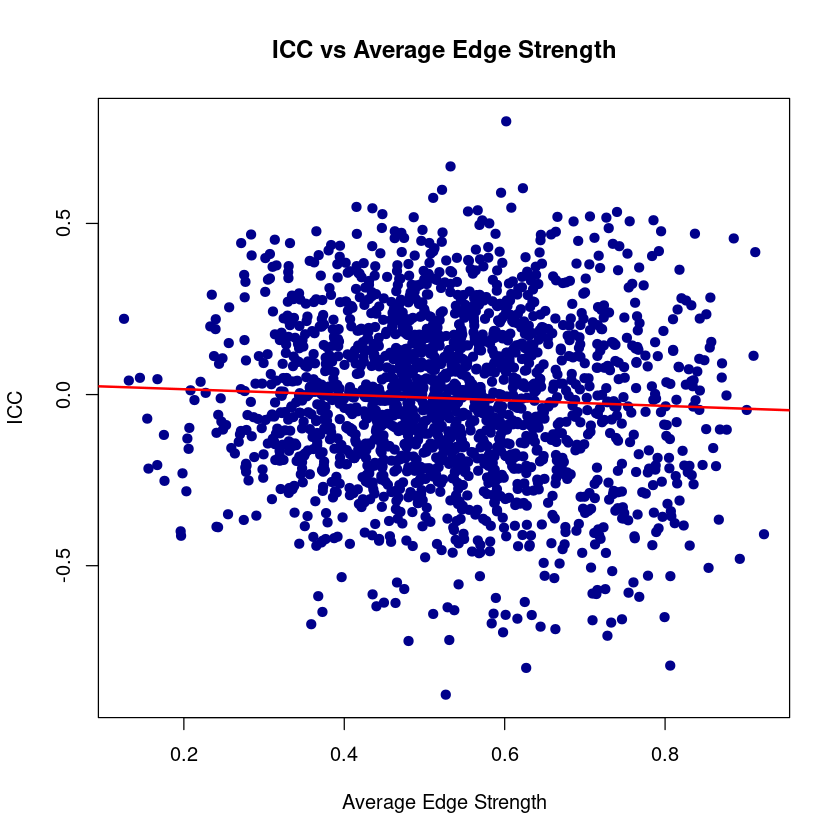

In [ ]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")
hist(icc_vals$ICC, breaks = 30, main = "Histogram of Between-paradigm ICC", xlab = "ICC", col = "skyblue")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_paradigm[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    main = "ICC vs Average Edge Strength",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

In [ ]:
icc_paradigm <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), stringsAsFactors = FALSE)

# Iterate over all possible combinations of repetition numbers for the 3 scanners
tasks <- unique(df_fc_paradigm$task)
for (rep1 in 1:12) {
  for (rep2 in 1:36) {

        # Extract that permutation of repetitions
        reps <- c(rep1, rep2)
        df_rep <- data.frame()
        for (i in 1:2) {
          df_one <- subset(df_fc_paradigm, task == tasks[i] & repetition == reps[i])
          df_rep <- rbind(df_rep, df_one)
        }
        colnames <- df_rep$task
        df_rep <- t(df_rep[, edge_keys])
        colnames(df_rep) <- colnames
        # Compute ICC(2,1) for this edge
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_paradigm <- rbind(icc_paradigm, data.frame(variability_type = "between-paradigm", task=NA, scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, days_diff = NA, summary_statistic = NA))
    }
}
head(df_rep)
icc_paradigm

,rest,rsmovie
edge1,0.3995341,0.3266557
edge2,0.4532716,0.4594529
edge3,0.7270787,0.5014879
edge4,0.7265083,0.6379796
edge5,0.3396650,0.3442520
edge6,0.3066537,0.3496748


variability_type,task,scanner,repetition,ICC,summary_statistic
<chr>,<lgl>,<chr>,<chr>,<dbl>,<lgl>
between-paradigm,NA,prisma,1-1,0.4166026,NA
between-paradigm,NA,prisma,1-2,0.4740292,NA
between-paradigm,NA,prisma,1-3,0.4793847,NA
between-paradigm,NA,prisma,1-4,0.4170954,NA
between-paradigm,NA,prisma,1-5,0.3687580,NA
between-paradigm,NA,prisma,1-6,0.5041669,NA
between-paradigm,NA,prisma,1-7,0.4110997,NA
between-paradigm,NA,prisma,1-8,0.4087863,NA
between-paradigm,NA,prisma,1-9,0.3844477,NA


Mean ICC across edges: 0.5649815 
Quantiles (25%, median, 75%): 0.40602 0.5326702 0.7256168 


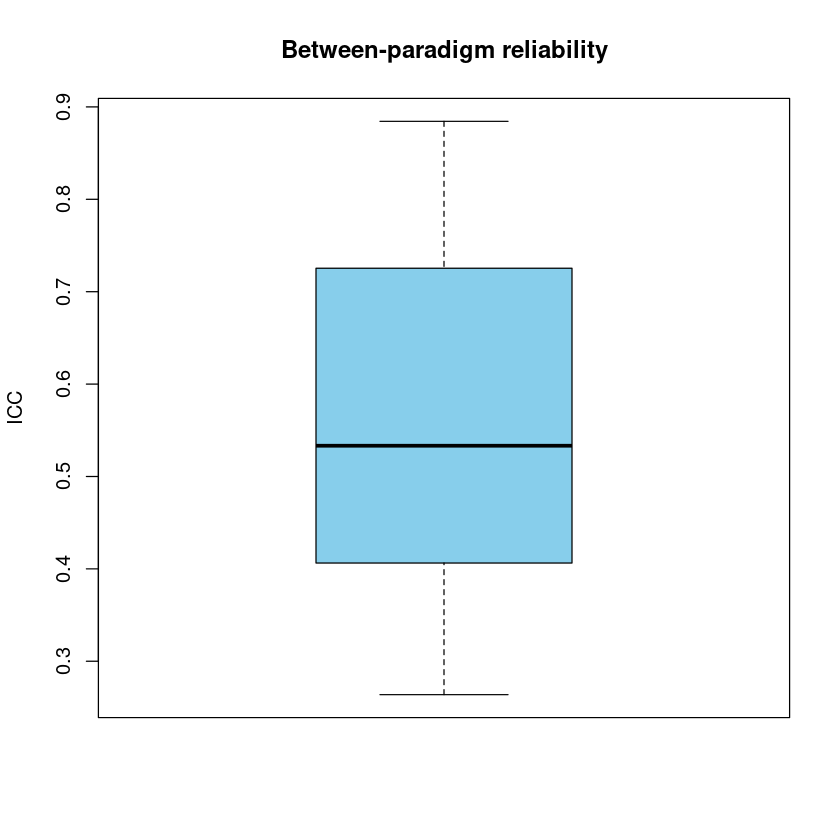

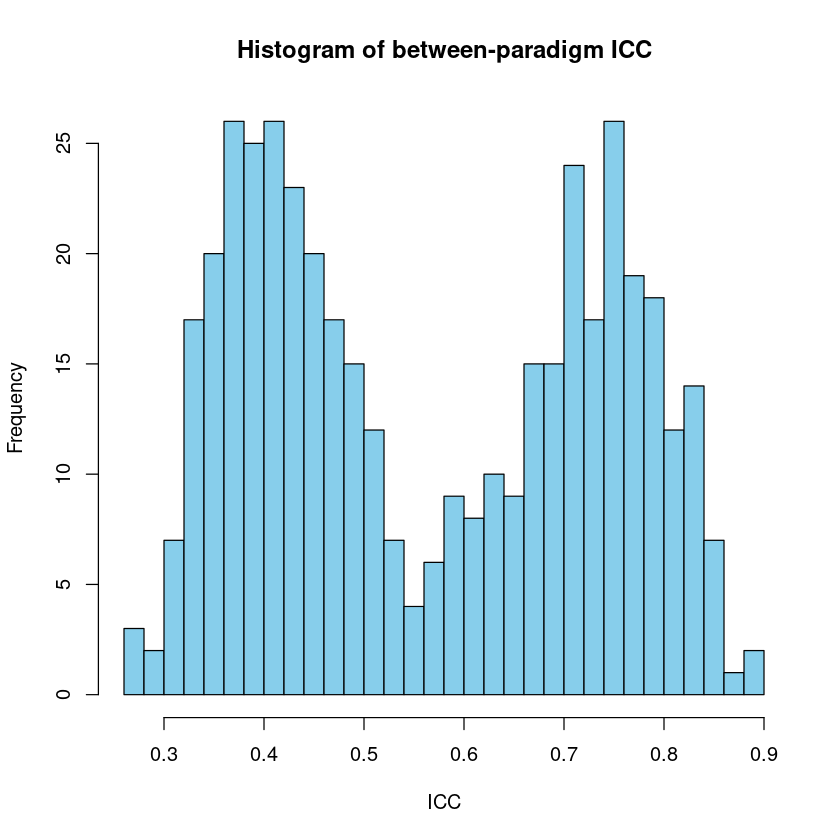

In [ ]:
mean_icc <- mean(icc_paradigm$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_paradigm$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_paradigm <- rbind(
    icc_paradigm,
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75")
)

boxplot(icc_paradigm$ICC, main = "Between-paradigm reliability", ylab = "ICC", col = "skyblue")
hist(icc_paradigm$ICC, breaks = 30, main = "Histogram of between-paradigm ICC", xlab = "ICC", col = "skyblue")

## Save the ICC estimates in a table

We use pybids to determine the filename to save the table.

In [ ]:
icc_results <- rbind(icc_between, icc_paradigm, icc_intra_rsmovie, icc_intra_rest)

py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)